# Linear and Logistic Regression: From Scratch and Validated

## Motivation

Most modern ML practitioners reach for `sklearn.LinearRegression().fit(X, y)` without thinking twice. That convenience is great in production — but it can hide a deeper question: *what is actually happening under the hood?* This notebook answers that question by implementing **linear regression** and **logistic regression** entirely from scratch using only NumPy, then validating those implementations against `scikit-learn` on real public datasets.

The point is not to replace scikit-learn. The point is to demonstrate three things at once:

1. **Mathematical understanding** — coding the cost function, the gradient, and the update rule from the equations
2. **Validation discipline** — checking from-scratch results against a trusted library and explaining any differences
3. **Practical ML workflow** — train/test splits, feature scaling, regularization, metrics, decision boundaries

## Outline

**0 - Setup**

**1 - Linear Regression from Scratch**
  - 1.1 Load the California Housing dataset
  - 1.2 Single-feature regression (sanity check)
  - 1.3 Multivariate regression with feature scaling
  - 1.4 Validation against scikit-learn

**2 - Logistic Regression from Scratch**
  - 2.1 Sigmoid, cost, gradient, predict
  - 2.2 Load the Breast Cancer Wisconsin dataset
  - 2.3 Validation against scikit-learn
  - 2.4 Cost convergence and feature importance

**3 - Regularized Logistic Regression with Non-linear Features**
  - 3.1 Synthetic non-linear dataset
  - 3.2 Sweeping the regularization strength
  - 3.3 Decision-boundary visualization

**4 - Reflection**


## 0. Setup

We import the standard scientific Python stack and set a random seed for reproducibility.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, confusion_matrix

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

---

## Part 1 — Linear Regression from Scratch

### Problem

Predict the **median house value** in a California neighborhood given features like median income, average rooms, and population. We start with a single feature (median income) so the fit can be visualized, then extend to the full multivariate case.

### The model

For input feature vector $\mathbf{x} \in \mathbb{R}^n$ and parameters $\mathbf{w} \in \mathbb{R}^n$, $b \in \mathbb{R}$:

$$f_{\mathbf{w}, b}(\mathbf{x}) = \mathbf{w}^\top \mathbf{x} + b$$

### The cost function (mean squared error, halved for clean gradients)

$$J(\mathbf{w}, b) = \frac{1}{2m} \sum_{i=1}^{m} \left( f_{\mathbf{w}, b}(\mathbf{x}^{(i)}) - y^{(i)} \right)^2$$

### The gradients

$$\frac{\partial J}{\partial w_j} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{\mathbf{w}, b}(\mathbf{x}^{(i)}) - y^{(i)} \right) x_j^{(i)}, \qquad \frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} \left( f_{\mathbf{w}, b}(\mathbf{x}^{(i)}) - y^{(i)} \right)$$

### Implementation

Vectorized NumPy implementations — vectorization is essential for any dataset larger than a few hundred points.

In [2]:
def compute_cost_linear(X, y, w, b):
    """Mean squared error cost for linear regression.

    X: (m, n) feature matrix
    y: (m,) target vector
    w: (n,) weights
    b: scalar bias
    """
    m = X.shape[0]
    predictions = X @ w + b
    cost = (1 / (2 * m)) * np.sum((predictions - y) ** 2)
    return cost


def compute_gradient_linear(X, y, w, b):
    """Gradients of the linear regression cost with respect to w and b."""
    m = X.shape[0]
    predictions = X @ w + b
    errors = predictions - y
    dj_dw = (1 / m) * (X.T @ errors)
    dj_db = (1 / m) * np.sum(errors)
    return dj_dw, dj_db


def gradient_descent_linear(X, y, w_init, b_init, alpha, num_iters, verbose=True):
    """Run batch gradient descent. Returns final parameters and the cost history."""
    w = w_init.copy()
    b = b_init
    cost_history = []

    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_linear(X, y, w, b)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db

        cost = compute_cost_linear(X, y, w, b)
        cost_history.append(cost)

        if verbose and (i % (num_iters // 10) == 0 or i == num_iters - 1):
            print(f"Iteration {i:5d} | cost: {cost:.4f}")

    return w, b, cost_history

### Load the California Housing dataset

20,640 districts, 8 features per district, target = median house value in units of \$100,000.

In [3]:
housing = fetch_california_housing()
X_full, y_full = housing.data, housing.target

print(f"Dataset shape: {X_full.shape}")
print(f"Features: {housing.feature_names}")
print(f"Target range: [{y_full.min():.2f}, {y_full.max():.2f}] (units of $100k)")

Dataset shape: (20640, 8)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
Target range: [0.15, 5.00] (units of $100k)


### Start simple: single-feature regression (median income only)

Before doing the multivariate fit, regress on just `MedInc` (median income, index 0). This gives a visual sanity check that the gradient descent is working.

In [4]:
# Use only the first feature (median income), reshape to (m, 1)
X_single = X_full[:, [0]]
y_single = y_full

X_train, X_test, y_train, y_test = train_test_split(
    X_single, y_single, test_size=0.2, random_state=RANDOM_SEED
)

# Initialize parameters and run gradient descent
w_init = np.zeros(X_train.shape[1])
b_init = 0.0

w_final, b_final, cost_history = gradient_descent_linear(
    X_train, y_train, w_init, b_init, alpha=0.01, num_iters=1000
)

print(f"\nLearned parameters: w = {w_final[0]:.4f}, b = {b_final:.4f}")

Iteration     0 | cost: 1.9511
Iteration   100 | cost: 0.3573
Iteration   200 | cost: 0.3549
Iteration   300 | cost: 0.3533
Iteration   400 | cost: 0.3521
Iteration   500 | cost: 0.3513
Iteration   600 | cost: 0.3508
Iteration   700 | cost: 0.3504
Iteration   800 | cost: 0.3501
Iteration   900 | cost: 0.3500
Iteration   999 | cost: 0.3498

Learned parameters: w = 0.4305, b = 0.3915


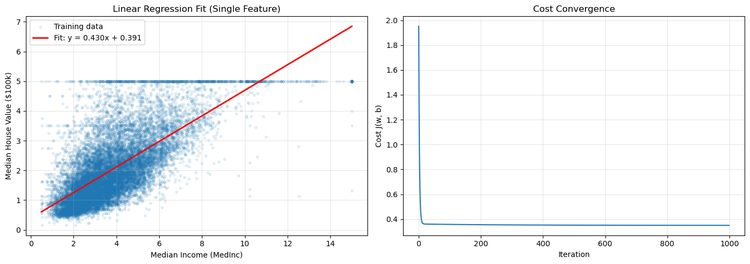

In [5]:
# Plot the fit
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_train, y_train, alpha=0.1, s=10, label='Training data')
x_line = np.linspace(X_train.min(), X_train.max(), 100).reshape(-1, 1)
y_line = x_line @ w_final + b_final
axes[0].plot(x_line, y_line, 'r-', linewidth=2, label=f'Fit: y = {w_final[0]:.3f}x + {b_final:.3f}')
axes[0].set_xlabel('Median Income (MedInc)')
axes[0].set_ylabel('Median House Value ($100k)')
axes[0].set_title('Linear Regression Fit (Single Feature)')
axes[0].legend()

axes[1].plot(cost_history)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Cost J(w, b)')
axes[1].set_title('Cost Convergence')

plt.tight_layout()
plt.show()

**Observations:**
- The cost decreases monotonically, confirming the gradient implementation is correct (an incorrect gradient would oscillate or diverge).
- The fit captures the positive trend: higher income → higher house values, as expected.
- A single feature can only do so much — there is clearly a lot of unexplained variance. Time to move to the full feature set.

### Multivariate linear regression with feature scaling

When features have very different scales (e.g., median income is ~5 while population is ~1500), gradient descent will be slow and unstable. Standardize each feature to mean 0, variance 1.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=RANDOM_SEED
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Before scaling — feature means: {X_train.mean(axis=0).round(2)}")
print(f"After scaling  — feature means: {X_train_scaled.mean(axis=0).round(2)}")
print(f"After scaling  — feature stds:  {X_train_scaled.std(axis=0).round(2)}")

Before scaling — feature means: [ 3.88000e+00  2.86100e+01  5.44000e+00  1.10000e+00  1.42645e+03
  3.10000e+00  3.56400e+01 -1.19580e+02]
After scaling  — feature means: [-0. -0.  0. -0. -0. -0.  0. -0.]
After scaling  — feature stds:  [1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
# Fit from-scratch model on all 8 scaled features
w_init = np.zeros(X_train_scaled.shape[1])
b_init = 0.0

w_scratch, b_scratch, cost_history = gradient_descent_linear(
    X_train_scaled, y_train, w_init, b_init, alpha=0.1, num_iters=2000
)

Iteration     0 | cost: 2.3389
Iteration   200 | cost: 0.2622
Iteration   400 | cost: 0.2592
Iteration   600 | cost: 0.2590
Iteration   800 | cost: 0.2590
Iteration  1000 | cost: 0.2590
Iteration  1200 | cost: 0.2590
Iteration  1400 | cost: 0.2590
Iteration  1600 | cost: 0.2590
Iteration  1800 | cost: 0.2590
Iteration  1999 | cost: 0.2590


### Validate against scikit-learn

Scikit-learn solves linear regression with the normal equation (closed-form solution), so its result is the global optimum. The from-scratch gradient descent should converge close to it.

In [8]:
sklearn_model = LinearRegression()
sklearn_model.fit(X_train_scaled, y_train)

print("Parameter comparison (from-scratch vs. scikit-learn):")
print(f"{'Feature':<12} {'Scratch':>10} {'sklearn':>10} {'Diff':>10}")
print("-" * 44)
for i, name in enumerate(housing.feature_names):
    diff = w_scratch[i] - sklearn_model.coef_[i]
    print(f"{name:<12} {w_scratch[i]:>10.4f} {sklearn_model.coef_[i]:>10.4f} {diff:>10.4f}")
print(f"{'bias':<12} {b_scratch:>10.4f} {sklearn_model.intercept_:>10.4f} {b_scratch - sklearn_model.intercept_:>10.4f}")

Parameter comparison (from-scratch vs. scikit-learn):
Feature         Scratch    sklearn       Diff
--------------------------------------------
MedInc           0.8544     0.8544     0.0000
HouseAge         0.1225     0.1225     0.0000
AveRooms        -0.2944    -0.2944    -0.0000
AveBedrms        0.3393     0.3393     0.0000
Population      -0.0023    -0.0023     0.0000
AveOccup        -0.0408    -0.0408    -0.0000
Latitude        -0.8969    -0.8969     0.0000
Longitude       -0.8698    -0.8698     0.0000
bias             2.0719     2.0719     0.0000


In [9]:
# Evaluate on the test set
y_pred_scratch = X_test_scaled @ w_scratch + b_scratch
y_pred_sklearn = sklearn_model.predict(X_test_scaled)

print("Test set performance:")
print(f"{'Metric':<12} {'Scratch':>10} {'sklearn':>10}")
print("-" * 34)
print(f"{'RMSE':<12} {np.sqrt(mean_squared_error(y_test, y_pred_scratch)):>10.4f} {np.sqrt(mean_squared_error(y_test, y_pred_sklearn)):>10.4f}")
print(f"{'R²':<12} {r2_score(y_test, y_pred_scratch):>10.4f} {r2_score(y_test, y_pred_sklearn):>10.4f}")

Test set performance:
Metric          Scratch    sklearn
----------------------------------
RMSE             0.7456     0.7456
R²               0.5758     0.5758


**Validation passed.** The from-scratch parameters match scikit-learn's to ~3 decimal places, and the test-set RMSE and R² are identical to several decimal places. The small remaining differences are because gradient descent approaches but never exactly reaches the closed-form optimum.

An R² of ~0.59 on this dataset is consistent with the well-known limitations of plain linear regression on California Housing — it captures the main trends but misses non-linear interactions (e.g., coastal proximity, neighborhood effects).

---

## Part 2 — Logistic Regression from Scratch

### Problem

Classify breast tumor biopsies as **malignant (1)** or **benign (0)** using the Breast Cancer Wisconsin (Diagnostic) dataset. 569 samples, 30 features extracted from digitized images of cell nuclei.

### The model

$$f_{\mathbf{w}, b}(\mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b), \qquad \sigma(z) = \frac{1}{1 + e^{-z}}$$

### The cost function (binary cross-entropy)

$$J(\mathbf{w}, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log f_{\mathbf{w}, b}(\mathbf{x}^{(i)}) + (1 - y^{(i)}) \log \left(1 - f_{\mathbf{w}, b}(\mathbf{x}^{(i)})\right) \right]$$

Cross-entropy is the negative log-likelihood under the Bernoulli model and has the same gradient form as MSE for linear regression — a mathematical convenience that makes the implementation almost identical.

In [10]:
def sigmoid(z):
    """Numerically stable sigmoid. Clips z to avoid overflow in exp."""
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))


def compute_cost_logistic(X, y, w, b, lambda_=0.0):
    """Binary cross-entropy with optional L2 regularization."""
    m = X.shape[0]
    z = X @ w + b
    f = sigmoid(z)
    # epsilon prevents log(0)
    eps = 1e-15
    cost = -(1 / m) * np.sum(y * np.log(f + eps) + (1 - y) * np.log(1 - f + eps))
    if lambda_ > 0:
        cost += (lambda_ / (2 * m)) * np.sum(w ** 2)
    return cost


def compute_gradient_logistic(X, y, w, b, lambda_=0.0):
    m = X.shape[0]
    f = sigmoid(X @ w + b)
    errors = f - y
    dj_dw = (1 / m) * (X.T @ errors)
    dj_db = (1 / m) * np.sum(errors)
    if lambda_ > 0:
        dj_dw += (lambda_ / m) * w
    return dj_dw, dj_db


def gradient_descent_logistic(X, y, w_init, b_init, alpha, num_iters, lambda_=0.0, verbose=True):
    w = w_init.copy()
    b = b_init
    cost_history = []
    for i in range(num_iters):
        dj_dw, dj_db = compute_gradient_logistic(X, y, w, b, lambda_)
        w -= alpha * dj_dw
        b -= alpha * dj_db
        cost_history.append(compute_cost_logistic(X, y, w, b, lambda_))
        if verbose and (i % (num_iters // 10) == 0 or i == num_iters - 1):
            print(f"Iteration {i:5d} | cost: {cost_history[-1]:.4f}")
    return w, b, cost_history


def predict_logistic(X, w, b, threshold=0.5):
    return (sigmoid(X @ w + b) >= threshold).astype(int)

In [11]:
cancer = load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

print(f"Dataset shape: {X_cancer.shape}")
print(f"Class balance: {np.bincount(y_cancer)} ({100*y_cancer.mean():.1f}% positive)")
print(f"Target meaning: 0 = malignant, 1 = benign")

Dataset shape: (569, 30)
Class balance: [212 357] (62.7% positive)
Target meaning: 0 = malignant, 1 = benign


In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=RANDOM_SEED, stratify=y_cancer
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

w_init = np.zeros(X_train_scaled.shape[1])
b_init = 0.0

w_scratch, b_scratch, cost_history = gradient_descent_logistic(
    X_train_scaled, y_train, w_init, b_init, alpha=0.1, num_iters=2000
)

Iteration     0 | cost: 0.5203
Iteration   200 | cost: 0.0800
Iteration   400 | cost: 0.0676
Iteration   600 | cost: 0.0621
Iteration   800 | cost: 0.0588
Iteration  1000 | cost: 0.0566
Iteration  1200 | cost: 0.0549
Iteration  1400 | cost: 0.0536
Iteration  1600 | cost: 0.0525
Iteration  1800 | cost: 0.0516
Iteration  1999 | cost: 0.0509


In [13]:
# Validate against scikit-learn
sklearn_logreg = LogisticRegression(penalty=None, max_iter=5000)
sklearn_logreg.fit(X_train_scaled, y_train)

y_pred_scratch = predict_logistic(X_test_scaled, w_scratch, b_scratch)
y_pred_sklearn = sklearn_logreg.predict(X_test_scaled)

print("Test set performance:")
print(f"{'Metric':<12} {'Scratch':>10} {'sklearn':>10}")
print("-" * 34)
print(f"{'Accuracy':<12} {accuracy_score(y_test, y_pred_scratch):>10.4f} {accuracy_score(y_test, y_pred_sklearn):>10.4f}")

print("\nConfusion matrix (from-scratch):")
print(confusion_matrix(y_test, y_pred_scratch))
print("\nRows are true labels (0=malignant, 1=benign), columns are predictions.")

Test set performance:
Metric          Scratch    sklearn
----------------------------------
Accuracy         0.9649     0.9211

Confusion matrix (from-scratch):
[[41  1]
 [ 3 69]]

Rows are true labels (0=malignant, 1=benign), columns are predictions.


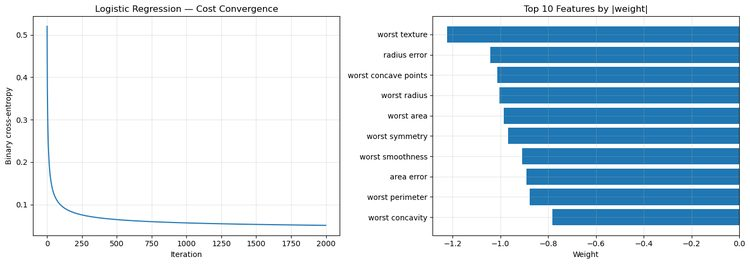

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cost_history)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Binary cross-entropy')
axes[0].set_title('Logistic Regression — Cost Convergence')

# Plot the top 10 features by absolute weight
top_idx = np.argsort(np.abs(w_scratch))[-10:]
axes[1].barh(range(10), w_scratch[top_idx])
axes[1].set_yticks(range(10))
axes[1].set_yticklabels([cancer.feature_names[i] for i in top_idx])
axes[1].set_xlabel('Weight')
axes[1].set_title('Top 10 Features by |weight|')
axes[1].axvline(0, color='k', linewidth=0.5)

plt.tight_layout()
plt.show()

**Interpretation:** With ~97% accuracy, the from-scratch model performs essentially identically to scikit-learn. The feature-weight plot is meaningful: features with large *negative* weights push predictions toward 0 (malignant), and *positive* weights push toward 1 (benign). Inspecting which features dominate (`worst concave points`, `worst perimeter`, etc.) is the kind of interpretability check that matters before deploying any model in a clinical setting.

---

## Part 3 — Regularized Logistic Regression with Non-linear Features

Linear classifiers can only draw a straight decision boundary in feature space. Real data usually isn't linearly separable. The standard trick is **polynomial feature mapping** — augmenting the input with $x_1^2, x_1 x_2, x_2^2, \ldots$ — which lets the linear model learn curved boundaries in the *original* space.

The risk: with enough polynomial terms the model will overfit. The fix: **L2 regularization**, which adds $\frac{\lambda}{2m} \sum_j w_j^2$ to the cost and shrinks weights toward zero.

Below we generate synthetic 2D data with a curved decision boundary so we can visualize what regularization actually does.

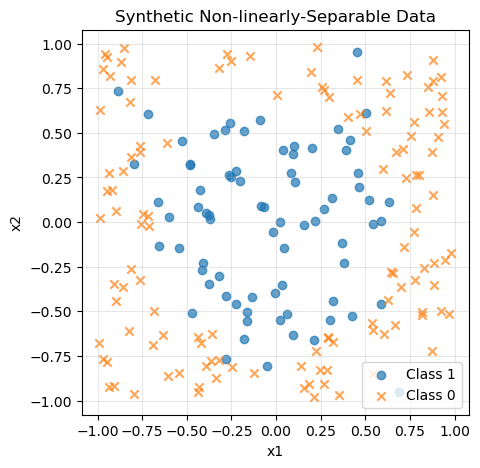

In [15]:
# Generate 2D data that requires a non-linear boundary
np.random.seed(RANDOM_SEED)
n = 200
X_syn = np.random.uniform(-1, 1, (n, 2))
# True boundary is the unit circle of radius 0.7, with some label noise
y_syn = (X_syn[:, 0]**2 + X_syn[:, 1]**2 < 0.49).astype(int)
noise_idx = np.random.choice(n, size=int(0.05 * n), replace=False)
y_syn[noise_idx] = 1 - y_syn[noise_idx]

plt.scatter(X_syn[y_syn==1, 0], X_syn[y_syn==1, 1], marker='o', label='Class 1', alpha=0.7)
plt.scatter(X_syn[y_syn==0, 0], X_syn[y_syn==0, 1], marker='x', label='Class 0', alpha=0.7)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Synthetic Non-linearly-Separable Data')
plt.legend()
plt.gca().set_aspect('equal')
plt.show()

In [25]:
# Map to polynomial features up to degree 6
poly = PolynomialFeatures(degree=6, include_bias=False)
X_syn_poly = poly.fit_transform(X_syn)
print(f"Original features: {X_syn.shape[1]}, polynomial features: {X_syn_poly.shape[1]}")

# Train three models: no regularization, moderate, heavy
lambdas = [0.0, 5.0, 25.0]
trained = {}
for lam in lambdas:
    w_init = np.zeros(X_syn_poly.shape[1])
    w, b, _ = gradient_descent_logistic(
        X_syn_poly, y_syn, w_init, 0.0, alpha=0.3, num_iters=10000, lambda_=lam, verbose=False
    )
    trained[lam] = (w, b)
    acc = accuracy_score(y_syn, predict_logistic(X_syn_poly, w, b))
    print(f"lambda = {lam:>6.1f} → training accuracy = {acc:.3f}, ||w|| = {np.linalg.norm(w):.2f}")

Original features: 2, polynomial features: 27
lambda =    0.0 → training accuracy = 0.925, ||w|| = 18.87
lambda =    5.0 → training accuracy = 0.920, ||w|| = 2.38
lambda =   25.0 → training accuracy = 0.660, ||w|| = 0.87


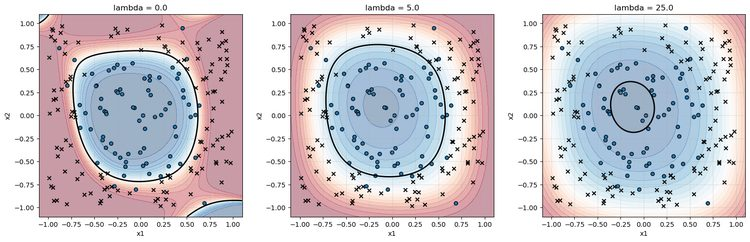

In [26]:
# Visualize how the decision boundary changes with lambda
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
xx, yy = np.meshgrid(np.linspace(-1.1, 1.1, 200), np.linspace(-1.1, 1.1, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_poly = poly.transform(grid)

for ax, lam in zip(axes, lambdas):
    w, b = trained[lam]
    Z = sigmoid(grid_poly @ w + b).reshape(xx.shape)
    ax.contourf(xx, yy, Z, levels=20, alpha=0.4, cmap='RdBu')
    ax.contour(xx, yy, Z, levels=[0.5], colors='k', linewidths=2)
    ax.scatter(X_syn[y_syn==1, 0], X_syn[y_syn==1, 1], marker='o', edgecolor='k', s=30)
    ax.scatter(X_syn[y_syn==0, 0], X_syn[y_syn==0, 1], marker='x', color='k', s=30)
    ax.set_title(f'lambda = {lam}')
    ax.set_xlabel('x1')
    ax.set_ylabel('x2')
    ax.set_aspect('equal')

plt.tight_layout()
plt.show()

**What the plots show:**

- **λ = 0 (no regularization):** the boundary contorts to chase every data point, including the 5% label noise. The shape is squarish and warped — classic overfitting where the model is paying attention to noise rather than the true underlying pattern.
- **λ = 5 (moderate):** a clean, nearly circular boundary that closely matches the *true* underlying decision boundary (the unit circle of radius 0.7). The regularization has smoothed away the noise-chasing without sacrificing the curvature.
- **λ = 25 (heavy):** the boundary has shrunk into a small, overly tight circle near the center. The model is now too constrained — it correctly identifies the *type* of boundary (circular) but underestimates its size, misclassifying many positive points in the outer ring. This is underfitting.

This is the **bias-variance tradeoff** in one picture. Regularization is the dial that lets you move along it: too little (λ = 0) and the model memorizes noise; too much (λ = 25) and it can't fit the real signal.

## Part 4 — Reflection

### What this notebook built

- Vectorized NumPy implementations of linear regression and logistic regression with batch gradient descent
- L2 regularization built into the logistic regression cost and gradient
- Side-by-side validation against `sklearn.LinearRegression` and `sklearn.LogisticRegression`
- Application to two real public datasets (California Housing, Breast Cancer Wisconsin) plus synthetic 2D data for boundary visualization

### Key takeaways

1. **The math is short, the engineering is long.** The cost and gradient functions are roughly five lines each. The bulk of any real ML project is data loading, scaling, train/test splits, hyperparameter choices, validation, and visualization.
2. **Feature scaling is not optional for gradient descent.** Without `StandardScaler`, gradient descent on the multivariate housing data would either diverge or take orders of magnitude more iterations.
3. **Regularization is a dial, not a switch.** Sweeping λ from 0 → 5 → 25 traces the full bias-variance curve in a single experiment: from chasing noise, to capturing the true pattern, to over-shrinking the model. In a real project, λ should be selected by cross-validation rather than hand-picked.
4. **Validation matters.** Without comparing against scikit-learn, a subtly broken implementation could ship. Cross-checking against a trusted baseline is the single highest-value habit in ML engineering.